In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## 1. Linearity Assumption

Linear Regression assumes that there is a **linear relationship** between the independent variables and the dependent variable.

In our case:

- R&D Spend → Profit
- Administration → Profit
- Marketing Spend → Profit

We can check this relationship using scatter plots.

If the relationship is approximately linear, the assumption is satisfied.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/datasets/amineoumous/50-startups-data/50_Startups.csv")

df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [3]:
df.shape

(50, 5)

In [4]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [8]:
X = df[['R&D Spend','Administration','Marketing Spend']]
y = df['Profit']

In [9]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50, 3)
y shape: (50,)


## 5. Checking Linearity

Linear Regression assumes that the relationship between the independent
variables and the dependent variable is approximately linear.

We will check this using scatter plots.

We will plot:

- R&D Spend vs Profit
- Administration vs Profit
- Marketing Spend vs Profit

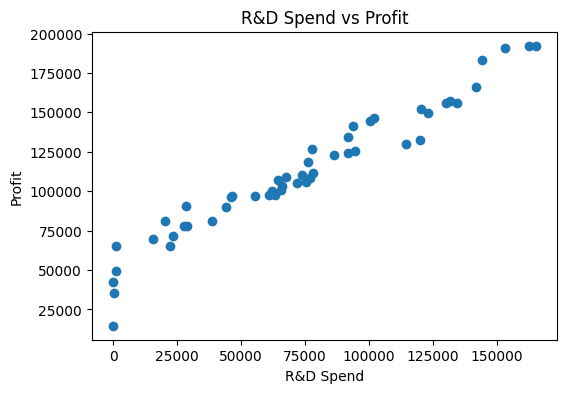

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(X['R&D Spend'],y)
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.title('R&D Spend vs Profit')
plt.show()

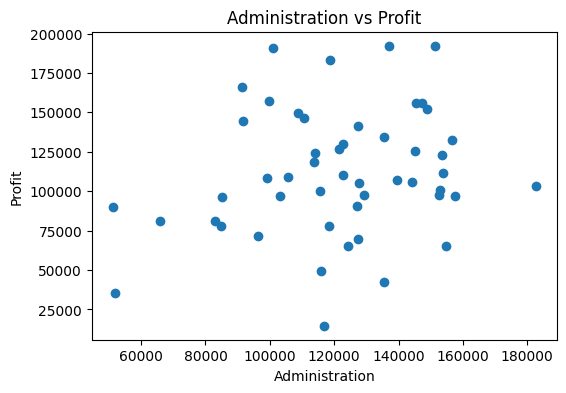

In [11]:
plt.figure(figsize=(6, 4))

plt.scatter(X['Administration'], y)

plt.xlabel('Administration')
plt.ylabel('Profit')
plt.title('Administration vs Profit')

plt.show()

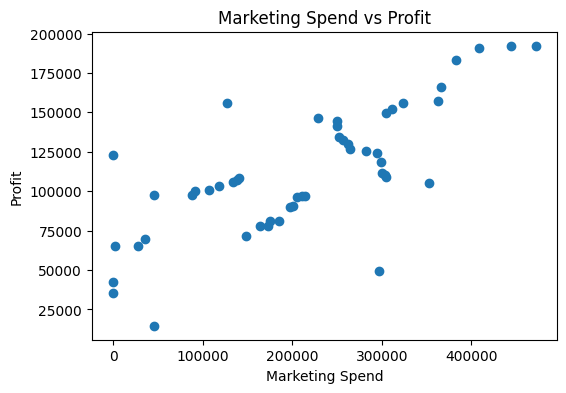

In [12]:
plt.figure(figsize=(6, 4))

plt.scatter(X['Marketing Spend'], y)

plt.xlabel('Marketing Spend')
plt.ylabel('Profit')
plt.title('Marketing Spend vs Profit')

plt.show()

## 6. Checking Multicollinearity

Multicollinearity occurs when two or more independent variables are
highly correlated with each other.

In our model, the independent variables are:

- R&D Spend
- Administration
- Marketing Spend

High multicollinearity can make it difficult for Linear Regression
to determine the individual effect of each feature.

We will first check this using a correlation matrix.

In [13]:
X.corr()

,R&D Spend,Administration,Marketing Spend
R&D Spend,1.000000,0.241955,0.724248
Administration,0.241955,1.000000,-0.032154
Marketing Spend,0.724248,-0.032154,1.000000


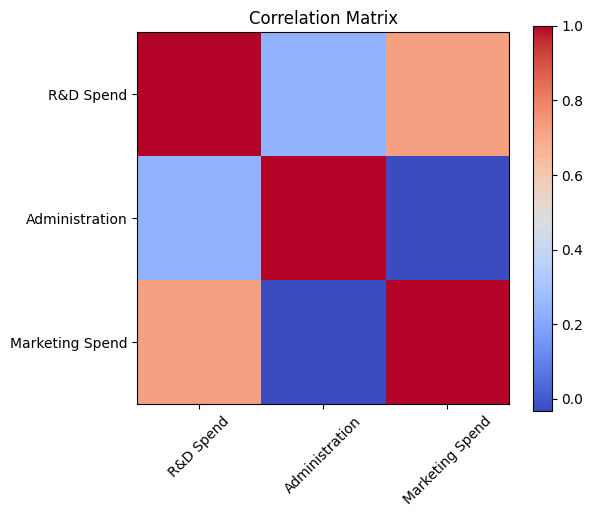

In [14]:
plt.figure(figsize=(6, 5))

plt.imshow(X.corr(), cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(X.columns)), X.columns, rotation=45)
plt.yticks(range(len(X.columns)), X.columns)

plt.title("Correlation Matrix")

plt.show()

## 7. Variance Inflation Factor (VIF)

Variance Inflation Factor (VIF) measures how much the variance of a
regression coefficient is increased because of multicollinearity.

The formula is:

$$
VIF = \frac{1}{1-R^2}
$$

where $R^2$ is obtained by predicting one independent variable using
the other independent variables.

### Interpretation

- **VIF = 1** → No multicollinearity
- **VIF < 5** → Generally acceptable
- **VIF > 5** → Possible multicollinearity
- **VIF > 10** → High multicollinearity

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [17]:
vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Feature,VIF
0,R&D Spend,8.384571
1,Administration,4.026406
2,Marketing Spend,7.593984


## 8. Checking Homoscedasticity

Homoscedasticity means that the variance of the residuals remains
approximately constant across all predicted values.

The residual is calculated as:

$$
Residual = Actual - Predicted
$$

We will plot the residuals against the predicted values.

If the residuals are randomly scattered around zero with a fairly
constant spread, the homoscedasticity assumption is satisfied.

In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [21]:
y_pred = model.predict(X)

In [22]:
residuals = y-y_pred

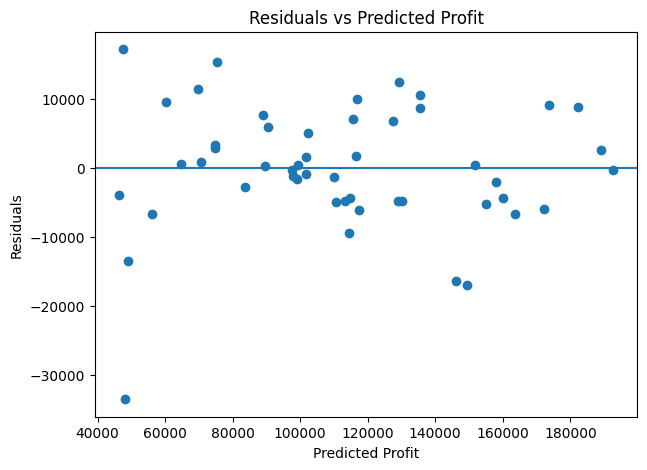

In [23]:
plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Profit")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Profit")

plt.show()

## 9. Checking Normality of Residuals

Linear Regression assumes that the residuals are approximately normally
distributed.

Residuals are the differences between the actual and predicted values:

$$
Residual = Actual - Predicted
$$

We can check the distribution of residuals using a histogram.

A roughly bell-shaped distribution indicates that the residuals are
approximately normally distributed.

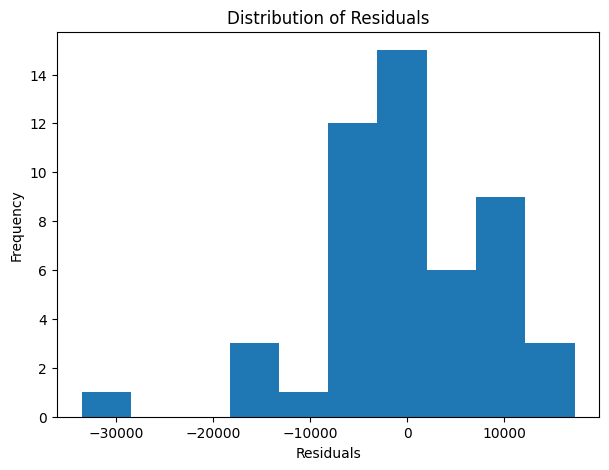

In [24]:
plt.figure(figsize=(7, 5))

plt.hist(residuals, bins=10)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

In [25]:
import statsmodels.api as sm

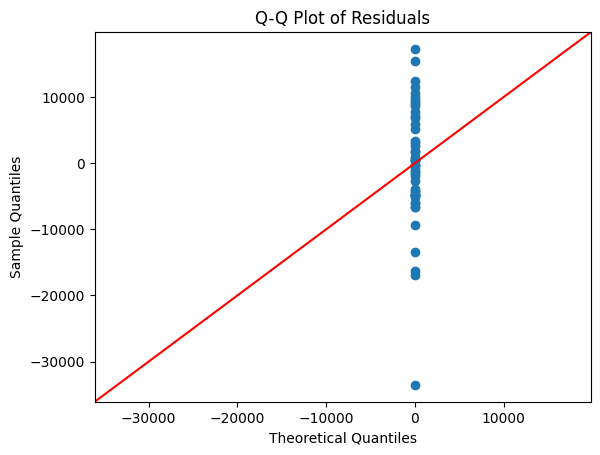

In [26]:
sm.qqplot(residuals, line='45')

plt.title("Q-Q Plot of Residuals")

plt.show()

## 10. Checking Autocorrelation

Autocorrelation occurs when the residuals are correlated with each other.

In Linear Regression, we generally assume that the residuals are
independent.

We can check this using the **Durbin-Watson test**.

The Durbin-Watson statistic ranges approximately from:

$$
0 \leq DW \leq 4
$$

Interpretation:

- **DW ≈ 2** → No autocorrelation
- **DW < 2** → Positive autocorrelation
- **DW > 2** → Negative autocorrelation

In [28]:
from statsmodels.stats.stattools import durbin_watson

In [29]:
dw = durbin_watson(residuals)

print("Durbin-Watson:", dw)

Durbin-Watson: 1.2817662007267283


## 11. Summary of Linear Regression Assumptions

We checked the major assumptions of Linear Regression:

### 1. Linearity
There should be an approximately linear relationship between the
independent variables and the target variable.

### 2. Multicollinearity
The independent variables should not be highly correlated with each other.

We used **VIF (Variance Inflation Factor)** to check this.

### 3. Homoscedasticity
The residuals should have approximately constant variance across
different predicted values.

### 4. Normality of Residuals
The residuals should be approximately normally distributed.

### 5. Autocorrelation
The residuals should be independent of each other.

We used the **Durbin-Watson test** to check for autocorrelation.

## 12. Model Performance

We will evaluate our Linear Regression model using:

- Mean Squared Error (MSE)
- R² Score

A lower MSE indicates smaller prediction errors, while a higher R²
indicates that the model explains more of the variation in the target.

In [33]:
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 78417126.01913083
R² Score: 0.9507459940683246
